## 0. Environment Setup

In [1]:
import warnings
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "accent": "#AB47BC",
}

TICKER = "SPY"
END = datetime.today()
START = END - timedelta(days=365 * 5)  # 5 years for V2 training
LOOKAHEAD = 5  # predict 5-bar ahead return

print("[NOTICE] This notebook trains V2 LEGACY models for use as")
print("         Behavioural Cloning teachers in notebook 09 (RL training).")
print("         These models are NOT used for live trading in Lumina V3.\n")

[NOTICE] This notebook trains V2 LEGACY models for use as
         Behavioural Cloning teachers in notebook 09 (RL training).
         These models are NOT used for live trading in Lumina V3.



## 1. Data Preparation (V2 Feature Set)

In [2]:
# V2 used a simpler feature set than V3 — no embeddings, no GNN.
# We reproduce the exact V2 features so the cloning baseline is fair.
raw = yf.download(
    TICKER,
    start=START,
    end=END,
    interval="1d",
    progress=False,
    auto_adjust=True,
)
raw.index = pd.to_datetime(raw.index)


def build_v2_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Reproduce the V2 AdvancedLSTM feature set exactly.
    Source: backend/archive/v2/ml_engine/features/
    """
    out = pd.DataFrame(index=df.index)

    # Price-based
    out["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
    out["high_low_pct"] = (df["High"] - df["Low"]) / df["Close"]
    out["close_open"] = (df["Close"] - df["Open"]) / df["Open"]

    # RSI
    delta = df["Close"].diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / 14, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / 14, adjust=False).mean()
    out["RSI"] = 100 - 100 / (1 + gain / loss.replace(0, np.nan))

    # MACD
    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()
    out["MACD"] = ema12 - ema26
    out["MACD_sig"] = out["MACD"].ewm(span=9, adjust=False).mean()

    # Bollinger %B
    sma = df["Close"].rolling(20).mean()
    std = df["Close"].rolling(20).std()
    out["BB_pct"] = (df["Close"] - (sma - 2 * std)) / (4 * std + 1e-10)

    # Volume
    out["vol_ratio"] = df["Volume"] / df["Volume"].rolling(20).mean()

    # Moving average ratios
    out["ma_ratio_20_50"] = (
        df["Close"].rolling(20).mean() / df["Close"].rolling(50).mean()
    )
    out["ma_ratio_50_200"] = (
        df["Close"].rolling(50).mean() / df["Close"].rolling(200).mean()
    )

    # Target: sign of N-bar-ahead return (classification label)
    future_return = df["Close"].shift(-LOOKAHEAD) / df["Close"] - 1
    out["target_return"] = future_return
    out["target_signal"] = (future_return > 0).astype(int)  # 1=Buy, 0=Sell/Hold

    return out.dropna()


features_v2 = build_v2_features(raw)
print(f"V2 feature set shape : {features_v2.shape}")
print(f"Target buy rate      : {features_v2['target_signal'].mean():.2%}")

V2 feature set shape : (1050, 12)
Target buy rate      : 59.14%


## 2. Walk-Forward Train / Test Split

In [3]:
# Walk-forward validation avoids look-ahead bias in time-series models.
# We use 5 folds — the last fold becomes the "Expert Labels" for V3 cloning.
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
FEATURE_COLS = [
    c
    for c in features_v2.columns
    if c not in ["target_return", "target_signal"]
]

X = features_v2[FEATURE_COLS].values
y_reg = features_v2["target_return"].values
y_clf = features_v2["target_signal"].values

splits = list(tscv.split(X))
print("Walk-forward splits:")
for i, (train_idx, test_idx) in enumerate(splits):
    print(
        f"  Fold {i + 1}: train [{train_idx[0]}:{train_idx[-1]}] "
        f"test [{test_idx[0]}:{test_idx[-1]}] "
        f"({len(test_idx)} bars)"
    )

Walk-forward splits:
  Fold 1: train [0:174] test [175:349] (175 bars)
  Fold 2: train [0:349] test [350:524] (175 bars)
  Fold 3: train [0:524] test [525:699] (175 bars)
  Fold 4: train [0:699] test [700:874] (175 bars)
  Fold 5: train [0:874] test [875:1049] (175 bars)


## 3. XGBoost Classifier — V2 Expert Signal Generator

In [4]:
try:
    import xgboost as xgb

    xgb_metrics: list[dict] = []
    xgb_all_preds = np.full(len(y_clf), np.nan)

    for fold, (train_idx, test_idx) in enumerate(splits):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_clf[train_idx], y_clf[test_idx]

        scaler = RobustScaler().fit(X_train)
        X_tr = scaler.transform(X_train)
        X_te = scaler.transform(X_test)

        model = xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=42,
            verbosity=0,
        )
        model.fit(X_tr, y_train, eval_set=[(X_te, y_test)], verbose=False)

        probs = model.predict_proba(X_te)[:, 1]
        preds = (probs >= 0.5).astype(int)
        xgb_all_preds[test_idx] = probs

        acc = (preds == y_test).mean()
        xgb_metrics.append(
            {"fold": fold + 1, "accuracy": acc, "n_test": len(y_test)}
        )
        print(f"  XGB Fold {fold + 1} → Accuracy: {acc:.4f}")

    print(
        "\n  XGB Mean Accuracy: "
        f"{np.mean([m['accuracy'] for m in xgb_metrics]):.4f}"
    )

except ImportError:
    print("XGBoost not installed.  Run: pip install xgboost")
    xgb_all_preds = None

  XGB Fold 1 → Accuracy: 0.5257
  XGB Fold 2 → Accuracy: 0.3486
  XGB Fold 3 → Accuracy: 0.5257
  XGB Fold 4 → Accuracy: 0.4343
  XGB Fold 5 → Accuracy: 0.6114

  XGB Mean Accuracy: 0.4891


## 4. LSTM Regressor — V2 Price Prediction Baseline

PyTorch device : cuda
  Epoch [5/20]  Loss: 0.000162
  Epoch [10/20]  Loss: 0.000157
  Epoch [15/20]  Loss: 0.000150
  Epoch [20/20]  Loss: 0.000148

  V2 LSTM Eval → MAE: 0.011807 | RMSE: 0.015326 | R²: -0.1327


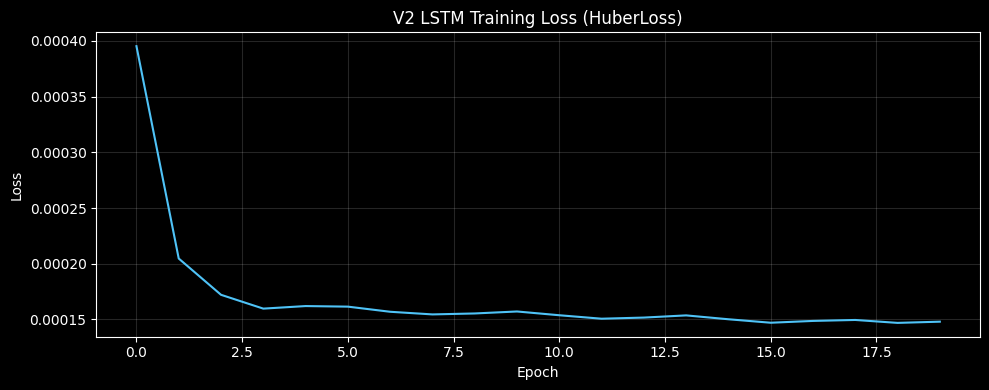


Expert LSTM saved → 03_v2_lstm_expert.pt
This checkpoint will be loaded in notebook 09 for Phase A cloning.


In [5]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    # LSTM sequence builder
    SEQ_LEN = 60  # 60-bar lookback window

    def make_sequences(X: np.ndarray, y: np.ndarray, seq_len: int) -> tuple:
        xs, ys = [], []
        for i in range(seq_len, len(X)):
            xs.append(X[i - seq_len : i])
            ys.append(y[i])
        return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)

    class V2LSTM(nn.Module):
        """
        V2 AdvancedLSTM architecture (archived).
        Serves as the Expert teacher for Phase A Behavioural Cloning.
        """

        def __init__(
            self,
            input_dim: int,
            hidden_dim: int = 128,
            num_layers: int = 2,
            dropout: float = 0.3,
        ):
            super().__init__()
            self.lstm = nn.LSTM(
                input_dim,
                hidden_dim,
                num_layers,
                batch_first=True,
                dropout=dropout,
            )
            self.head = nn.Sequential(
                nn.Linear(hidden_dim, 64),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(64, 1),
                nn.Tanh(),  # Return prediction bounded in [-1, 1]
            )

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            out, _ = self.lstm(x)
            return self.head(out[:, -1, :]).squeeze(-1)

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch device : {DEVICE}")

    # Train on last fold only (sufficient for Expert label generation)
    train_idx, test_idx = splits[-1]
    scaler_lstm = RobustScaler().fit(X[train_idx])
    X_tr = scaler_lstm.transform(X[train_idx])
    X_te = scaler_lstm.transform(X[test_idx])
    y_tr = y_reg[train_idx]
    y_te = y_reg[test_idx]

    X_tr_seq, y_tr_seq = make_sequences(X_tr, y_tr, SEQ_LEN)
    X_te_seq, y_te_seq = make_sequences(X_te, y_te, SEQ_LEN)

    dataset_tr = TensorDataset(torch.tensor(X_tr_seq), torch.tensor(y_tr_seq))
    loader_tr = DataLoader(dataset_tr, batch_size=64, shuffle=False)

    model_lstm = V2LSTM(input_dim=X_tr.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(
        model_lstm.parameters(), lr=1e-3, weight_decay=1e-4
    )
    criterion = nn.HuberLoss(delta=0.01)

    # Training loop — 20 epochs (quick baseline)
    N_EPOCHS = 20
    train_losses = []

    model_lstm.train()
    for epoch in range(N_EPOCHS):
        epoch_loss = 0.0
        for xb, yb in loader_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model_lstm(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader_tr)
        train_losses.append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch [{epoch + 1}/{N_EPOCHS}]  Loss: {avg_loss:.6f}")

    # Evaluation
    model_lstm.eval()
    with torch.no_grad():
        X_te_t = torch.tensor(X_te_seq).to(DEVICE)
        lstm_preds = model_lstm(X_te_t).cpu().numpy()

    mae = mean_absolute_error(y_te_seq, lstm_preds)
    rmse = np.sqrt(mean_squared_error(y_te_seq, lstm_preds))
    r2 = r2_score(y_te_seq, lstm_preds)
    print(
        f"\n  V2 LSTM Eval → MAE: {mae:.6f} | RMSE: {rmse:.6f} | R²: {r2:.4f}"
    )

    # Training loss curve
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_losses, color=COLORS["primary"], linewidth=1.5)
    ax.set_title("V2 LSTM Training Loss (HuberLoss)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.savefig("03/03_lstm_loss.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Save model as Expert teacher
    torch.save(model_lstm.state_dict(), "03/03_v2_lstm_expert.pt")
    print("\nExpert LSTM saved → 03_v2_lstm_expert.pt")
    print("This checkpoint will be loaded in notebook 09 for Phase A cloning.")

except ImportError:
    print("PyTorch not installed.  Run: pip install torch")
    model_lstm = None
    lstm_preds = None

## 5. Expert Label Export for Behavioural Cloning (Phase A)

In [6]:
# Generate the Expert signal dataset that notebook 09 will use.
# Format: for each timestep → [state_features, expert_action]
# where expert_action encodes the V2 signal as a V3-compatible action vector.


def v2_signal_to_v3_action(xgb_proba: float) -> np.ndarray:
    """
    Map V2 XGBoost probability to the V3 continuous action vector.
    V3 action space (§5):
      action[0] direction  : [-1.0, +1.0]  — long/short
      action[1] urgency    : [0.0,  1.0]   — limit/market order
      action[2] sizing     : [0.0,  1.0]   — fraction of risk capital
      action[3] stop_dist  : [0.0,  1.0]   — stop loss ATR multiplier
    """
    if xgb_proba is None or np.isnan(xgb_proba):
        return np.array(
            [0.0, 0.3, 0.0, 0.5]
        )  # flat / limit / no size / mid stop

    direction = (xgb_proba - 0.5) * 2.0  # map [0,1] → [-1, 1]
    conviction = abs(xgb_proba - 0.5) * 2.0  # 0=low, 1=high conviction
    sizing = conviction * 0.5  # max 50% risk capital (conservative V2)
    urgency = 0.4 if conviction < 0.6 else 0.8  # limit for low, market for high
    stop_dist = 1.0 - conviction * 0.5  # wider stops for low conviction

    return np.array([direction, urgency, sizing, stop_dist], dtype=np.float32)


if xgb_all_preds is not None:
    expert_valid = ~np.isnan(xgb_all_preds)
    expert_actions = np.array(
        [
            (
                v2_signal_to_v3_action(p)
                if valid
                else v2_signal_to_v3_action(np.nan)
            )
            for p, valid in zip(xgb_all_preds, expert_valid, strict=False)
        ]
    )

    expert_df = pd.DataFrame(
        {
            "date": features_v2.index,
            "xgb_proba": xgb_all_preds,
            "v3_direction": expert_actions[:, 0],
            "v3_urgency": expert_actions[:, 1],
            "v3_sizing": expert_actions[:, 2],
            "v3_stop_dist": expert_actions[:, 3],
            "target_return": features_v2["target_return"].values,
        }
    ).set_index("date")

    expert_df.dropna(inplace=True)
    expert_df.to_parquet("03/03_expert_labels.parquet")
    print("Expert labels saved → 03/03_expert_labels.parquet")
    print(f"Shape: {expert_df.shape}")
    print(expert_df.tail(5).to_string())
else:
    print("XGBoost not available — expert labels not generated.")
    print("Install xgboost and re-run to generate labels for notebook 09.")

Expert labels saved → 03/03_expert_labels.parquet
Shape: (875, 6)
            xgb_proba  v3_direction  v3_urgency  v3_sizing  v3_stop_dist  target_return
date                                                                                   
2026-02-25   0.547870      0.095741         0.4   0.047870      0.952130      -0.011570
2026-02-26   0.485252     -0.029495         0.4   0.014748      0.985252      -0.011591
2026-02-27   0.532060      0.064121         0.4   0.032060      0.967940      -0.019840
2026-03-02   0.322644     -0.354712         0.4   0.177356      0.822644      -0.011816
2026-03-03   0.549922      0.099844         0.4   0.049922      0.950078      -0.004410


## 6. V2 vs. V3 Performance Baseline

In [7]:
# Compute V2 buy-and-hold benchmark to establish the performance bar
# that V3 must exceed during Phase C (Pure RL — §7-C).
buy_hold_return = float(
    (raw["Close"].iloc[-1] / raw["Close"].iloc[0] - 1) * 100
)
annual_vol = float(raw["Close"].pct_change().std() * np.sqrt(252) * 100)
years = (raw.index[-1] - raw.index[0]).days / 365
cagr = float(
    ((raw["Close"].iloc[-1] / raw["Close"].iloc[0]) ** (1 / years) - 1) * 100
)

print("=" * 50)
print("  V2 BASELINE PERFORMANCE TARGETS FOR V3")
print("=" * 50)
print(f"  Asset          : {TICKER}")
print(f"  Period         : {START.date()} → {END.date()}")
print(f"  Buy & Hold     : {buy_hold_return:+.1f}%")
print(f"  CAGR           : {cagr:+.1f}%")
print(f"  Ann. Volatility: {annual_vol:.1f}%")
if xgb_all_preds is not None:
    print(
        "  XGB Accuracy   : "
        f"{np.mean([m['accuracy'] for m in xgb_metrics]):.2%}"
    )

  V2 BASELINE PERFORMANCE TARGETS FOR V3
  Asset          : SPY
  Period         : 2021-03-11 → 2026-03-10
  Buy & Hold     : +84.1%
  CAGR           : +13.0%
  Ann. Volatility: 17.0%
  XGB Accuracy   : 48.91%
